<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/09_fiscal_federalism_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Figures in ₹ Lakh Crore
raw_fiscal_data = """Fiscal_Year,Corporation_Tax,Income_Tax,Customs_Excise,CGST,Cesses_Surcharges,Actual_Devolution_to_States
FY20,5.57,4.93,4.10,5.99,2.95,6.51
FY21,4.58,4.87,4.52,5.49,3.68,5.95
FY22,7.12,6.96,5.15,6.98,5.19,8.83
FY23,8.26,8.33,4.72,8.49,5.08,9.48
FY24,9.23,10.22,4.88,9.58,5.45,10.97
FY25,10.20,11.56,5.05,10.62,6.01,12.47
"""

with open("fiscal_federalism_data.csv", "w") as f:
    f.write(raw_fiscal_data.strip())

print("fiscal_federalism_data.csv created successfully.")

fiscal_federalism_data.csv created successfully.


In [2]:
df_fiscal = pd.read_csv("fiscal_federalism_data.csv")

# 1. Total Gross Tax Revenue (GTR)
df_fiscal["Gross_Tax_Revenue"] = (
    df_fiscal["Corporation_Tax"]
    + df_fiscal["Income_Tax"]
    + df_fiscal["Customs_Excise"]
    + df_fiscal["CGST"]
    + df_fiscal["Cesses_Surcharges"]
)

# 2. Divisible Pool (GTR minus non-shareable cesses and surcharges)
df_fiscal["Divisible_Pool"] = (
    df_fiscal["Gross_Tax_Revenue"] - df_fiscal["Cesses_Surcharges"]
)

# 3. Statutory 41% benchmark recommended by 15th Finance Commission
df_fiscal["Statutory_41%_Target"] = df_fiscal["Divisible_Pool"] * 0.41

# 4. Effective Devolution as % of Gross Tax Revenue (GTR)
df_fiscal["Effective_Devolution_%"] = (
    df_fiscal["Actual_Devolution_to_States"] / df_fiscal["Gross_Tax_Revenue"]
) * 100

# 5. Cesses & Surcharges as % of Gross Tax Revenue
df_fiscal["Cesses_Share_of_GTR_%"] = (
    df_fiscal["Cesses_Surcharges"] / df_fiscal["Gross_Tax_Revenue"]
) * 100

print("--- Fiscal Federalism Audit Table ---")
print(
    df_fiscal[
        [
            "Fiscal_Year",
            "Gross_Tax_Revenue",
            "Divisible_Pool",
            "Actual_Devolution_to_States",
            "Effective_Devolution_%",
            "Cesses_Share_of_GTR_%",
        ]
    ].round(2)
)

--- Fiscal Federalism Audit Table ---
  Fiscal_Year  Gross_Tax_Revenue  Divisible_Pool  Actual_Devolution_to_States  \
0        FY20              23.54           20.59                         6.51   
1        FY21              23.14           19.46                         5.95   
2        FY22              31.40           26.21                         8.83   
3        FY23              34.88           29.80                         9.48   
4        FY24              39.36           33.91                        10.97   
5        FY25              43.44           37.43                        12.47   

   Effective_Devolution_%  Cesses_Share_of_GTR_%  
0                   27.66                  12.53  
1                   25.71                  15.90  
2                   28.12                  16.53  
3                   27.18                  14.56  
4                   27.87                  13.85  
5                   28.71                  13.84  


In [3]:
# Compute cumulative transfers and devolution wedge
total_gtr = df_fiscal["Gross_Tax_Revenue"].sum()
total_cesses = df_fiscal["Cesses_Surcharges"].sum()
total_devolution = df_fiscal["Actual_Devolution_to_States"].sum()
total_statutory_benchmark = df_fiscal["Statutory_41%_Target"].sum()

avg_effective_rate = df_fiscal["Effective_Devolution_%"].mean()
avg_cess_share = df_fiscal["Cesses_Share_of_GTR_%"].mean()

print(f"Cumulative Gross Tax Revenue: ₹{total_gtr:,.2f} Lakh Cr")
print(f"Cumulative Cesses & Surcharges: ₹{total_cesses:,.2f} Lakh Cr")
print(f"Cumulative Actual Devolution:  ₹{total_devolution:,.2f} Lakh Cr")
print(
    f"Cumulative 41% Statutory Target: ₹{total_statutory_benchmark:,.2f} Lakh Cr\n"
)
print(f"Mean Effective Devolution Share of GTR: {avg_effective_rate:.2f}%")
print(f"Mean Cesses & Surcharges Share of GTR:  {avg_cess_share:.2f}%")

Cumulative Gross Tax Revenue: ₹195.76 Lakh Cr
Cumulative Cesses & Surcharges: ₹28.36 Lakh Cr
Cumulative Actual Devolution:  ₹54.21 Lakh Cr
Cumulative 41% Statutory Target: ₹68.63 Lakh Cr

Mean Effective Devolution Share of GTR: 27.54%
Mean Cesses & Surcharges Share of GTR:  14.53%


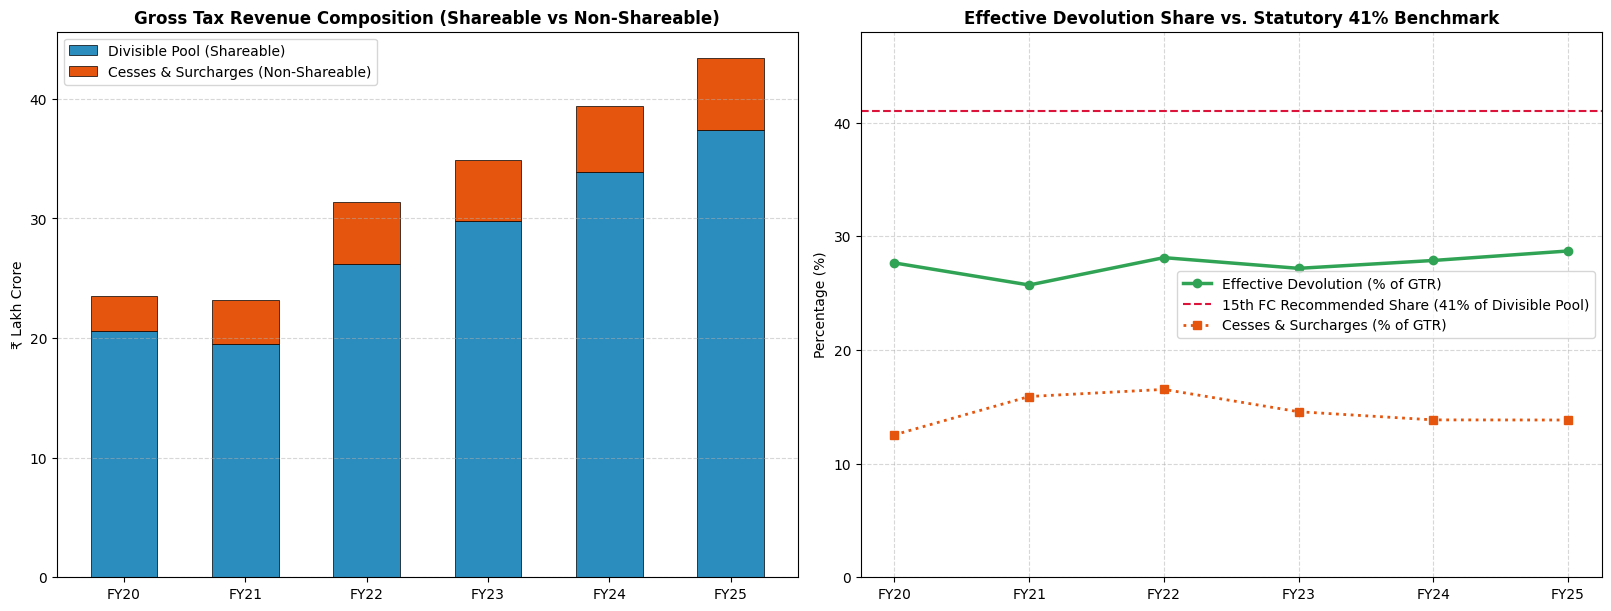

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Composition of Gross Tax Revenue (Stacked Bar) ---
x = np.arange(len(df_fiscal["Fiscal_Year"]))
width = 0.55

p1 = ax1.bar(
    x,
    df_fiscal["Divisible_Pool"],
    width,
    label="Divisible Pool (Shareable)",
    color="#2b8cbe",
    edgecolor="black",
    linewidth=0.5,
)
p2 = ax1.bar(
    x,
    df_fiscal["Cesses_Surcharges"],
    width,
    bottom=df_fiscal["Divisible_Pool"],
    label="Cesses & Surcharges (Non-Shareable)",
    color="#e6550d",
    edgecolor="black",
    linewidth=0.5,
)

ax1.set_title(
    "Gross Tax Revenue Composition (Shareable vs Non-Shareable)",
    fontsize=12,
    weight="bold",
)
ax1.set_ylabel("₹ Lakh Crore")
ax1.set_xticks(x)
ax1.set_xticklabels(df_fiscal["Fiscal_Year"])
ax1.legend(loc="upper left")
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# --- Chart 2: Statutory 41% Mandate vs Effective State Devolution ---
ax2.plot(
    df_fiscal["Fiscal_Year"],
    df_fiscal["Effective_Devolution_%"],
    color="#31a354",
    linewidth=2.5,
    marker="o",
    label="Effective Devolution (% of GTR)",
)
ax2.axhline(
    41.0,
    color="crimson",
    linestyle="--",
    linewidth=1.5,
    label="15th FC Recommended Share (41% of Divisible Pool)",
)

# Plot trend of Cesses & Surcharges share
ax2.plot(
    df_fiscal["Fiscal_Year"],
    df_fiscal["Cesses_Share_of_GTR_%"],
    color="#e6550d",
    linewidth=2,
    linestyle=":",
    marker="s",
    label="Cesses & Surcharges (% of GTR)",
)

ax2.set_title(
    "Effective Devolution Share vs. Statutory 41% Benchmark",
    fontsize=12,
    weight="bold",
)
ax2.set_ylabel("Percentage (%)")
ax2.set_ylim(0, 48)
ax2.legend(loc="center right")
ax2.grid(True, linestyle="--", alpha=0.5)

plt.show()